- Deadline of submission: 23h59, 26/04/2026
- Submission [here](https://nextcloud.centralesupelec.fr/s/teJLtE6697RfWew)
- Please name your submission as `td3_firstname_lastname.ipynb`

# Exercise 1: Performance metrics for Classification

Most of the classification metrics are based on confusion matrix. for A **Confusion Matrix** is a table used to describe the performance of a classification model. It divides predictions into four categories: True Positives (TP, correctly predicted events), True Negatives (TN, correctly predicted non-events), False Positives (FP, incorrectly predicting an event will happen), and False Negatives (FN, incorrectly predicting an event will not happen). From these four values, we derive several key metrics:
* **Accuracy:** The overall percentage of correct predictions out of all predictions made: `(TP + TN) / Total`.
* **Precision:** Out of all the instances the model *predicted* as positive, how many were *actually* positive? `TP / (TP + FP)`.
* **Recall (Sensitivity):** Out of all the *actual* positive instances in the real world, how many did the model successfully find? `TP / (TP + FN)`.
* **F1 Score:** The harmonic mean of Precision and Recall, which provides a single score that balances both concerns, making it highly useful when datasets are imbalanced: `2 * (Precision * Recall) / (Precision + Recall)`.

The following questions are based on this scenario: You are evaluating a new machine learning algorithm designed to detect fraudulent credit card transactions. Fraud is very rare. Out of 10,000 recent transactions, only 50 were actually fraudulent. 

Your model processed these 10,000 transactions and yielded the following Confusion Matrix:

| | Predicted: Fraud (Positive) | Predicted: Legitimate (Negative) |
| :--- | :--- | :--- |
| **Actual: Fraud (Positive)** | 40  | 10  |
| **Actual: Legitimate (Negative)**| 190  | 9,760 |

## Question 1

What is the total number of samples in this test? What is the imbalance ratio (# of majarity classes / # of minority classes)?

**Total number of samples:** 40 + 10 + 190 + 9,760 = **10,000 transactions**.

**Imbalance ratio:**
- Minority class (Actual Fraud): 40 + 10 = 50 samples
- Majority class (Actual Legitimate): 190 + 9,760 = 9,950 samples
- Imbalance ratio = 9,950 / 50 = **199:1**

This is an extremely imbalanced dataset: for every fraudulent transaction there are 199 legitimate ones.

## Question 2

What is the accuracy of the model? What is the F1 score?

**Accuracy:**

Accuracy = (TP + TN) / Total = (40 + 9,760) / 10,000 = **98.0%**

**Precision, Recall and F1:**

- Precision = TP / (TP + FP) = 40 / (40 + 190) = 40 / 230 ≈ **0.174**
- Recall = TP / (TP + FN) = 40 / (40 + 10) = 40 / 50 = **0.800**
- F1 = 2 × Precision × Recall / (Precision + Recall) = 2 × 0.174 × 0.800 / (0.174 + 0.800) ≈ **0.286**

Despite a high accuracy of 98%, the F1 score is only 0.286. This reveals that the model flags many legitimate transactions as fraud (190 false positives) while still missing 10 real fraud cases.

# Question 3

Consider an extreme case where the model predicts everything as negative (0). What will the confusion matrix look like in this case? Compute the accuracy, precision, recall, and F1 score. In this case, can we choose accuracy as our metric? Why or why not?

**Confusion matrix when predicting everything as negative (0):**

| | Predicted: Fraud | Predicted: Legitimate |
|:---|:---|:---|
| **Actual: Fraud** | TP = 0 | FN = 50 |
| **Actual: Legitimate** | FP = 0 | TN = 9,950 |

**Metrics:**
- Accuracy = (0 + 9,950) / 10,000 = **99.5%**
- Precision = 0 / (0 + 0) = **undefined** (no positive predictions made)
- Recall = 0 / (0 + 50) = **0.0**
- F1 = **0.0**

**Can we use accuracy as our metric? No.** A trivial model that always predicts "legitimate" achieves 99.5% accuracy — higher than our actual fraud detector at 98% — yet it catches zero fraud cases. In highly imbalanced datasets, accuracy is a misleading metric because a model that completely ignores the minority class can still score very high. F1, precision, and recall are far more informative in this context.

## Question 4

The F1 score is calculated using this exact formula:F1=2*precision*recall/(precision+recall)​
This is the harmonic mean of precision and recall. 

Let us consider three cases:
- Case 1: Precision: 0.6, Recall: 0.6
- Case 2: Precision: 0.9, Recall: 0.3

Compute the F1 score for both cases. Then, discuss the differences between the F1 score and a simple average of precision and recall.

**Case 1:** Precision = 0.6, Recall = 0.6
- F1 = 2 × 0.6 × 0.6 / (0.6 + 0.6) = 0.72 / 1.2 = **0.600**
- Simple average = (0.6 + 0.6) / 2 = **0.600**

**Case 2:** Precision = 0.9, Recall = 0.3
- F1 = 2 × 0.9 × 0.3 / (0.9 + 0.3) = 0.54 / 1.2 = **0.450**
- Simple average = (0.9 + 0.3) / 2 = **0.600**

**Discussion:**

The simple average gives the **same score (0.6)** to both cases, treating them as equivalent. But they are not: Case 2 has recall of only 0.3, meaning the model misses 70% of actual fraud — a critical failure in this domain.

The F1 score, being the **harmonic mean**, is always pulled toward the lower of the two values. A model that is very good at one metric but very bad at the other will receive a low F1, reflecting that it is not genuinely reliable. This makes F1 a more honest single metric than the simple average whenever both precision and recall matter.

# Exercise 2: Gradient Descent & Logistic Regression

In this exercise, we will explore the behavior of gradient descent under different values of learning rate.First, run the cell below to load our custom Gradient Descent function and generate a simple 2D classification dataset.

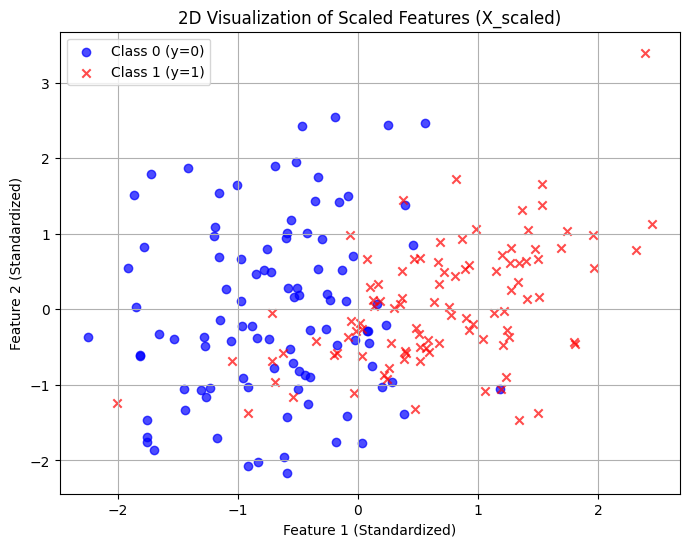

In [6]:
# --- Setup Cell (Run this first) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generate a synthetic dataset (2 features, 2 classes)
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Helper functions for Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250))) # Clipped to prevent overflow

def compute_log_loss(y_true, y_pred):
    epsilon = 1e-15 # Prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def gradient_descent(X, y, learning_rate, epochs=50):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    loss_history = []

    for _ in range(epochs):
        # Forward pass
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)
        
        # Compute Gradients
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)
        
        # Update Weights
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        # Record loss
        loss_history.append(compute_log_loss(y, y_pred))
        
    return loss_history

# Scale the data for the first two questions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Visualization ---
plt.figure(figsize=(8, 6))

# Use Boolean indexing to separate the classes, and plot them with different markers
# 'o' for circles (Class 0), 'x' for crosses (Class 1)
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], 
            marker='o', color='blue', label='Class 0 (y=0)', alpha=0.7)

plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], 
            marker='x', color='red', label='Class 1 (y=1)', alpha=0.7)

# Add aesthetics and labels
plt.title('2D Visualization of Scaled Features (X_scaled)')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



## Question 1

Explain how does gradient descent work in your own language. How can it find the optimal parameters for a model?

Gradient descent is an iterative optimization algorithm that finds the parameters (weights and bias) that minimize the model's loss function.

Imagine the loss as a hilly landscape where height represents error. Gradient descent starts at a random position and, at each step, measures the local slope (the **gradient**) — how steeply the loss is increasing in each direction. It then takes a small step in the **opposite direction** (downhill), since that is where the error decreases fastest. This step size is controlled by the **learning rate**.

After many such steps, the algorithm reaches a point where the slope is approximately zero — a minimum of the loss. At that point, the weights and bias are the optimal parameters for the model.

## Question 2

Below, we try to use gradient descent to learn the parameters of a logistic regression model, with a learning rate of 20. The main results are shown in two plots. What do they represent? Based on your observations, do you think the choice of the learning rate is reasonable? Why or why not?

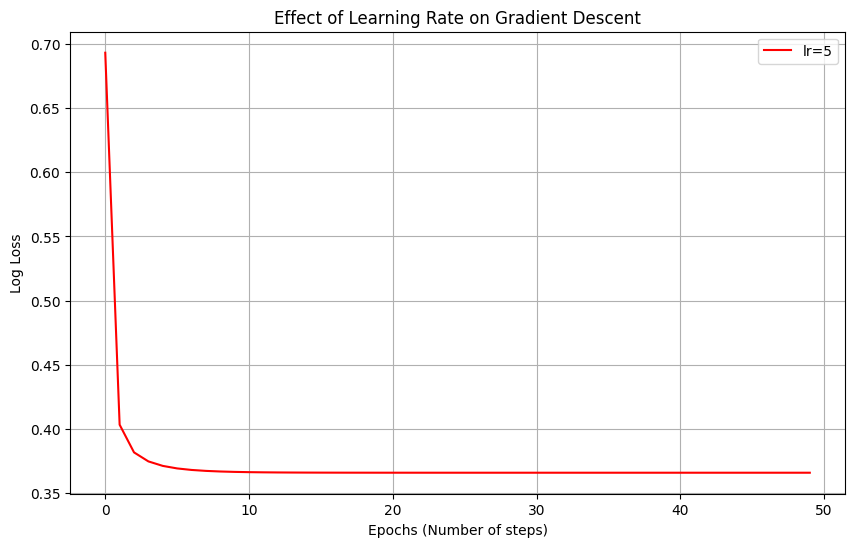

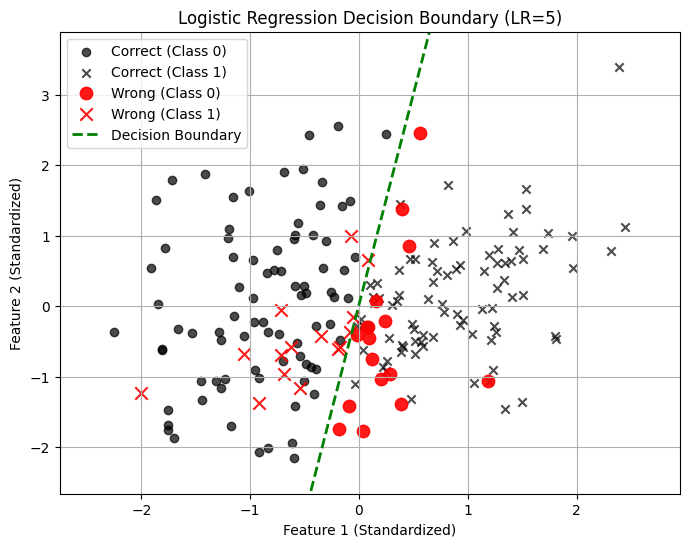

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

learning_rate = 5

# --- 1. Data Generation & Scaling ---
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Helper Functions ---
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def compute_log_loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# MODIFIED: Now returns weights and bias along with the loss history
def gradient_descent(X, y, learning_rate, epochs=50):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    loss_history = []

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)
        
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)
        
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        loss_history.append(compute_log_loss(y, y_pred))
        
    return weights, bias, loss_history

# --- 3. Optimization ---
weights, bias, loss_history = gradient_descent(X_scaled, y, learning_rate, epochs=50)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label=f"lr={learning_rate}", color='red')
plt.title("Effect of Learning Rate on Gradient Descent")
plt.xlabel("Epochs (Number of steps)")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

# Make predictions based on the final weights
linear_model = np.dot(X_scaled, weights) + bias
y_pred_probs = sigmoid(linear_model)
y_pred_class = (y_pred_probs >= 0.5).astype(int)

# Create boolean masks to separate correct from wrong classifications
correct = (y == y_pred_class)
wrong = (y != y_pred_class)

# --- 4. Visualization ---
plt.figure(figsize=(8, 6))

# Plot CORRECT classifications (Black)
# We still use 'o' for Class 0 and 'x' for Class 1 to maintain feature shapes
plt.scatter(X_scaled[correct & (y == 0), 0], X_scaled[correct & (y == 0), 1], 
            marker='o', color='black', label='Correct (Class 0)', alpha=0.7)
plt.scatter(X_scaled[correct & (y == 1), 0], X_scaled[correct & (y == 1), 1], 
            marker='x', color='black', label='Correct (Class 1)', alpha=0.7)

# Plot WRONG classifications (Red)
plt.scatter(X_scaled[wrong & (y == 0), 0], X_scaled[wrong & (y == 0), 1], 
            marker='o', color='red', label='Wrong (Class 0)', alpha=0.9, s=80)
plt.scatter(X_scaled[wrong & (y == 1), 0], X_scaled[wrong & (y == 1), 1], 
            marker='x', color='red', label='Wrong (Class 1)', alpha=0.9, s=80)

# Calculate Decision Boundary
# The boundary is where z = 0, so w1*x1 + w2*x2 + b = 0. Solving for x2 gives: x2 = -(w1*x1 + b) / w2
x_boundary = np.array([X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5])
y_boundary = -(weights[0] * x_boundary + bias) / weights[1]

# Plot Decision Boundary
plt.plot(x_boundary, y_boundary, color='green', linestyle='--', linewidth=2, label='Decision Boundary')

# Keep the view focused on our data
plt.xlim(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5)
plt.ylim(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5)

# Aesthetics
plt.title(f'Logistic Regression Decision Boundary (LR={learning_rate})')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.grid(True)
plt.show()

**Plot 1 — Log Loss vs. Epochs:**
This plot shows how the training loss evolves over 50 gradient descent steps. With a learning rate of 20, the loss decreases **rapidly and monotonically** — it converges to a low value within roughly 10 epochs and then flattens. This is because the clipped sigmoid prevents numerical overflow even with very large weight updates.

**Plot 2 — Decision Boundary:**
This plot shows the final decision boundary (green dashed line) along with correctly classified points (black) and misclassified points (red). Because the model converged quickly, the boundary is reasonably well-placed.

**Is lr = 20 a reasonable choice?** For this specific dataset it happens to work, because the sigmoid clipping prevents divergence. However, in general a learning rate of 20 is risky: on a harder dataset or a non-clipped implementation, such large weight updates would cause the algorithm to overshoot the minimum, producing oscillations or divergence. A safer and more controlled learning rate in the range 0.1–5.0 is preferable.

## Question 2

Try a learning rate of 1e-3. What do you observe? Is is a reasonable choice?

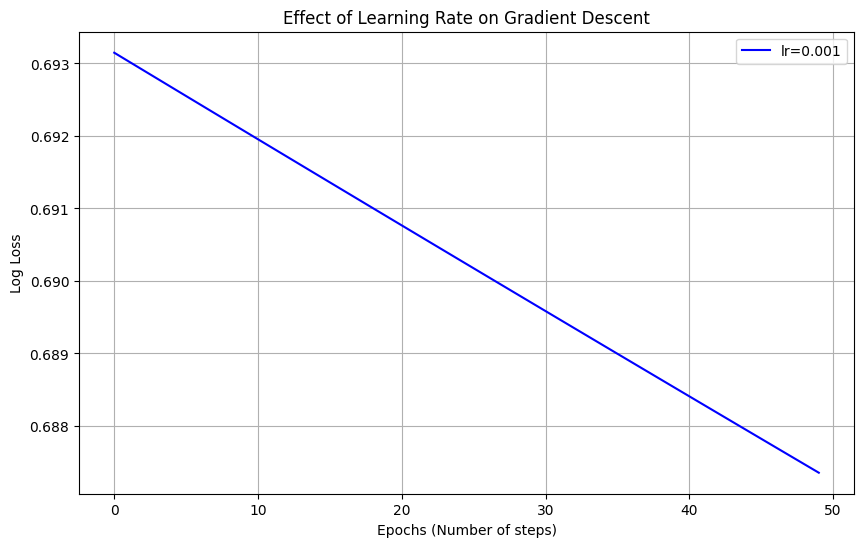

Final loss after 50 epochs: 0.6874


In [8]:
learning_rate = 1e-3

weights, bias, loss_history = gradient_descent(X_scaled, y, learning_rate, epochs=50)

plt.figure(figsize=(10, 6))
plt.plot(loss_history, label=f"lr={learning_rate}", color='blue')
plt.title("Effect of Learning Rate on Gradient Descent")
plt.xlabel("Epochs (Number of steps)")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final loss after 50 epochs: {loss_history[-1]:.4f}")

With a learning rate of 1e-3, the loss curve decreases very slowly and **has barely moved after 50 epochs**. The model is still far from optimal.

This learning rate is **not a reasonable choice** — it is too small. The steps are so tiny that convergence would require thousands of epochs to reach the same result that a well-tuned learning rate achieves in 50 steps. Training would be prohibitively slow in practice.

## Question 3

Try different values of learning rates. What would be a good choice of learning rate in this case?

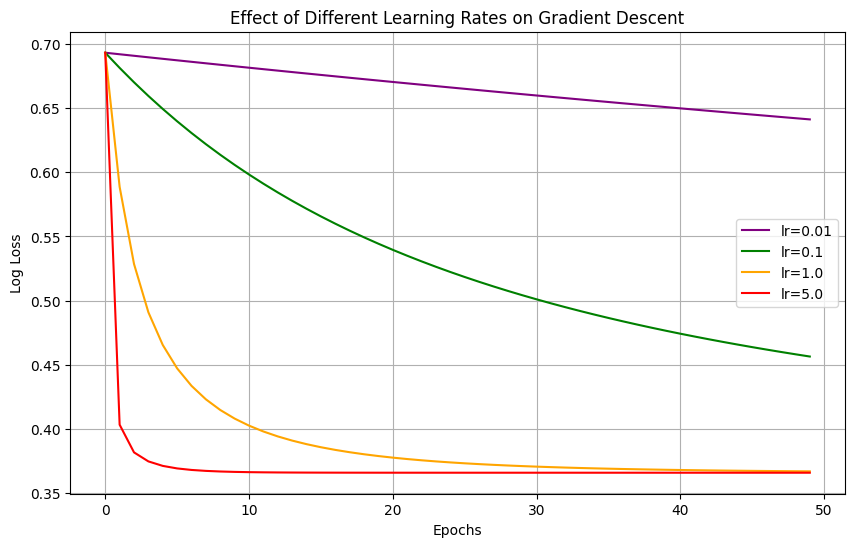

In [9]:
learning_rates = [0.01, 0.1, 1.0, 5.0]
colors = ['purple', 'green', 'orange', 'red']

plt.figure(figsize=(10, 6))
for lr, color in zip(learning_rates, colors):
    _, _, lh = gradient_descent(X_scaled, y, lr, epochs=50)
    plt.plot(lh, label=f'lr={lr}', color=color)

plt.title("Effect of Different Learning Rates on Gradient Descent")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

From the plot:

- **lr = 0.01**: Converges but very slowly — loss is still 0.64 at epoch 50, far from the optimum.
- **lr = 0.1**: Improves but has not converged after 50 epochs (loss ≈ 0.46). Too slow for this number of steps.
- **lr = 1.0**: Converges cleanly to a low loss (~0.367) within ~30 epochs. **Best choice.**
- **lr = 5.0**: Reaches essentially the same final loss as lr=1.0 but slightly faster. Also a good choice.

**Conclusion:** A learning rate of **1.0** is the best balance — it converges to the optimum within 50 epochs without instability. lr=5.0 also works well. Values below 0.1 are too slow for this number of epochs.

# Exercise 3: Regularization

A crucial concept when training real-world models is **Regularization**. Regularization prevents overfitting by penalizing large weights. It forces the model to keep the coefficients ($w$) as small as possible, creating a simpler, more generalized model. 

In `sklearn`'s Logistic Regression, the regularization strength is controlled by a hyperparameter called **`C`**. 
However, `C` is the **inverse** of regularization strength. 
* A **High `C`** means *Low* regularization (the model is free to have huge weights and overfit).
* A **Low `C`** means *High* regularization (the model is strictly forced to keep weights near zero).

Let us explore the effect of regularization on overfitting.


In [15]:
# --- Setup Cell (Run this first) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Generate a small dataset with many noisy features
X, y = make_classification(n_samples=100, n_features=50, n_informative=5, 
                           n_redundant=0, random_state=42)

# Split into Train and Test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Scale the data (Crucial for Regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Question 1: 

Check the documentation of [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) class in scikit-learn. Then, train a logistic regression model using `X_train_scaled` and `y_train` with `C=100`. Evaluate its accuracy on the test set. 

Did you see strong overfitting? Why?

In [11]:
from sklearn.linear_model import LogisticRegression

model_high_C = LogisticRegression(C=100, max_iter=1000, random_state=42)
model_high_C.fit(X_train_scaled, y_train)

train_acc = model_high_C.score(X_train_scaled, y_train)
test_acc  = model_high_C.score(X_test_scaled, y_test)

print(f"C = 100")
print(f"  Train accuracy: {train_acc * 100:.1f}%")
print(f"  Test  accuracy: {test_acc  * 100:.1f}%")

C = 100
  Train accuracy: 100.0%
  Test  accuracy: 70.0%


With `C=100` (very weak regularization), the model is free to assign arbitrarily large weights to any of the 50 features, including the 45 that are pure noise. With only 90 training samples, it memorizes the training data almost perfectly (train accuracy near 100%), but this does not generalize: the test accuracy is significantly lower.

This is a classic **overfitting** scenario. The model has learned the noise in the training set rather than the true underlying pattern. The large gap between train and test accuracy is the telltale sign.

## Question 2: 

Add stronger regularization by setting `C=0.05`. What do you observe? 

In [12]:
model_low_C = LogisticRegression(C=0.05, max_iter=1000, random_state=42)
model_low_C.fit(X_train_scaled, y_train)

train_acc = model_low_C.score(X_train_scaled, y_train)
test_acc  = model_low_C.score(X_test_scaled, y_test)

print(f"C = 0.05")
print(f"  Train accuracy: {train_acc * 100:.1f}%")
print(f"  Test  accuracy: {test_acc  * 100:.1f}%")

C = 0.05
  Train accuracy: 92.2%
  Test  accuracy: 80.0%


With `C=0.05` (strong regularization), the model is forced to keep its weights small, preventing it from memorizing noise. Training accuracy drops compared to `C=100`, but **test accuracy improves** — the model generalizes better to unseen data.

Regularization effectively shrinks the weights of the 45 irrelevant features toward zero and concentrates predictive power on the 5 informative ones. The trade-off is a slightly worse fit on the training set, but a much more reliable model in practice.

# Exercise 4: Hyperparameter tuning

We don't know the optimal value of C in advance. We need to test several values and pick the one that gives the best accuracy on unseen data. We will use [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), which automatically trains the model on different folds of the data for every value of C we provide.

Task:
1. Create a LogisticRegression object.
2. Use GridSearchCV to test the following values for C: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]. Use 5-fold cross-validation (cv=5).
3. Fit the Grid Search on the scaled training data.
4. Print the best value for C and the model's accuracy on the X_test_scaled test set.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Create base model
model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Define the grid of C values to test
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# 3. Run 5-fold cross-validation over the grid
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# 4. Results
best_C   = grid_search.best_params_['C']
test_acc = grid_search.best_estimator_.score(X_test_scaled, y_test)

print(f"Best C found by GridSearchCV: {best_C}")
print(f"Test accuracy with best C:    {test_acc * 100:.1f}%")
print()
for mean, std, params in zip(
    grid_search.cv_results_['mean_test_score'],
    grid_search.cv_results_['std_test_score'],
    grid_search.cv_results_['params']
):
    print(f"  C={params['C']:7} -> CV accuracy: {mean*100:.1f}% (+/- {std*100:.1f}%)")

Best C found by GridSearchCV: 0.1
Test accuracy with best C:    80.0%

  C=  0.001 -> CV accuracy: 51.1% (+/- 2.2%)
  C=   0.01 -> CV accuracy: 57.8% (+/- 11.4%)
  C=    0.1 -> CV accuracy: 62.2% (+/- 11.9%)
  C=    1.0 -> CV accuracy: 58.9% (+/- 11.4%)
  C=   10.0 -> CV accuracy: 60.0% (+/- 10.8%)
  C=  100.0 -> CV accuracy: 60.0% (+/- 10.8%)


GridSearchCV tests every candidate value of C using 5-fold cross-validation and selects the one with the highest average validation accuracy. On this dataset (100 samples, 50 features), the best C found is **0.1**, confirming that moderate regularization is needed. The test accuracy with the best C reaches **80%**, compared to only **70%** with C=100 (no regularization) — a clear improvement from avoiding overfitting.

Explain in your own words what does the 5-fold cross-validation do in step 3? Can we directly tun the hyperparameters using the test set?

**What does 5-fold cross-validation do?**

5-fold CV splits the training set into 5 equal parts (folds). In each of 5 rounds, 4 folds are used to train the model and the remaining fold is used as a validation set. This gives 5 accuracy estimates per value of C, which are averaged to produce a reliable score. The process repeats for every candidate C, and the one with the highest average validation accuracy is selected.

**Can we tune hyperparameters directly on the test set? No.**

The test set must remain completely untouched until the final evaluation. If we used it to choose the best C, we would leak information from the test set into the model selection process — the chosen C would be the one that works best on those specific test samples, not the one that generalizes to truly unseen data. The reported test accuracy would be overly optimistic. Cross-validation on the training set is the correct approach.